# 04 — v3: Fine-tuning the Transformer (the experiment that won)

**Story so far:**
- v1: TF–IDF + Logistic Regression → macro-F1 **0.866** (production baseline)
- v2 (notebook 03): **frozen** sentence embeddings lost — even with an MLP head
  (best 0.673). Conclusion: frozen embeddings are the floor, not the ceiling.

**This notebook tests the obvious next step:** actually **fine-tune** the
transformer end-to-end (unfreeze its weights) on our six-tone task, using the
*same* MiniLM backbone as v2 so the comparison is clean.

**Result: it won.** Fine-tuned MiniLM reaches **macro-F1 0.915**, beating TF–IDF by
~5 points and lifting every class — including the previously-weak `stress` and
`loneliness`. Training took ~53s on Apple MPS.

> Code: `src/train_finetune.py` (plain PyTorch loop, class-weighted loss, MPS/CPU).
> Metrics below are recorded from that run.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. The approach progression (dair-ai held-out macro-F1)

In [2]:
progression = pd.Series({
    "TF-IDF + LogReg":      0.866,
    "Frozen embed + LogReg":0.597,
    "Frozen embed + MLP":   0.673,
    "Fine-tuned MiniLM":    0.915,
})
progression.to_frame("macro_F1")

,macro_F1
TF-IDF + LogReg,0.866
Frozen embed + LogReg,0.597
Frozen embed + MLP,0.673
Fine-tuned MiniLM,0.915


/tmp/claude-501/ipykernel_30425/3335679210.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a1.set_xticklabels(progression.index, rotation=20, ha="right"); a1.grid(axis="y", alpha=.3)


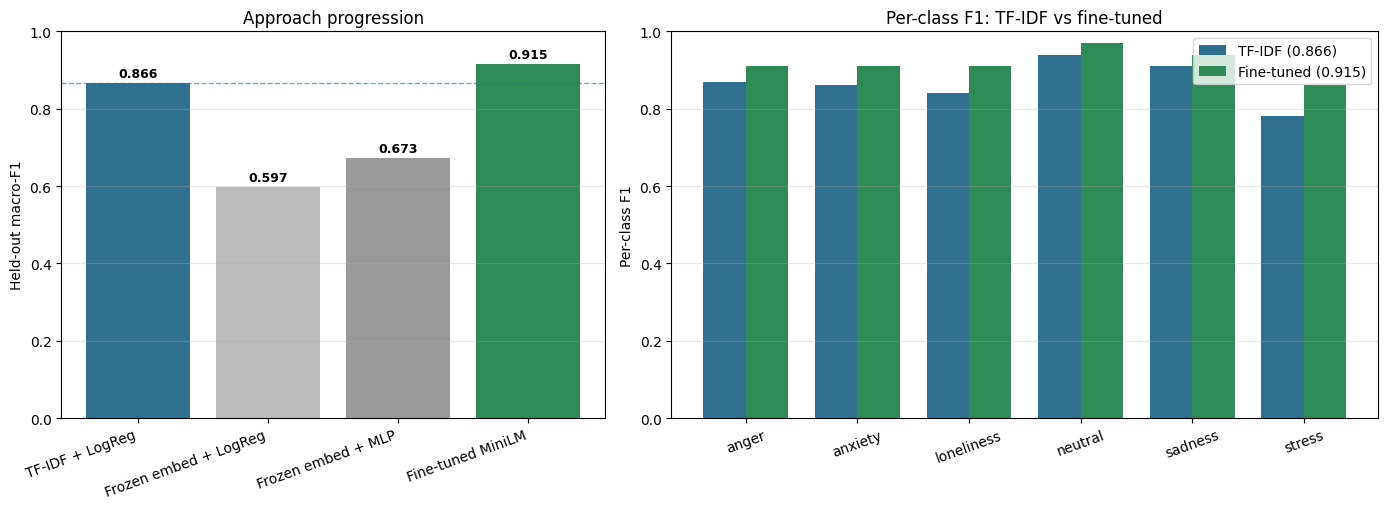

In [3]:
tones = ["anger", "anxiety", "loneliness", "neutral", "sadness", "stress"]
tfidf = [0.87, 0.86, 0.84, 0.94, 0.91, 0.78]
ft    = [0.91, 0.91, 0.91, 0.97, 0.94, 0.86]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={"width_ratios": [1, 1.3]})
colors = ["#2f6f8f", "#bbb", "#999", "#2e8b57"]
bars = a1.bar(progression.index, progression.values, color=colors)
a1.axhline(0.866, ls="--", lw=1, color="#2f6f8f", alpha=.6)
a1.set_ylim(0, 1); a1.set_ylabel("Held-out macro-F1"); a1.set_title("Approach progression")
a1.set_xticklabels(progression.index, rotation=20, ha="right"); a1.grid(axis="y", alpha=.3)
for b, v in zip(bars, progression.values):
    a1.text(b.get_x() + b.get_width()/2, v + .015, f"{v:.3f}", ha="center", fontweight="bold", fontsize=9)

x = np.arange(len(tones)); w = 0.38
a2.bar(x - w/2, tfidf, w, label="TF-IDF (0.866)", color="#2f6f8f")
a2.bar(x + w/2, ft,    w, label="Fine-tuned (0.915)", color="#2e8b57")
a2.set_xticks(x); a2.set_xticklabels(tones, rotation=20)
a2.set_ylim(0, 1); a2.set_ylabel("Per-class F1")
a2.set_title("Per-class F1: TF-IDF vs fine-tuned"); a2.legend(); a2.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

## 2. Where the gains came from

The biggest per-class jumps are exactly the tones that hurt before:

| Tone | TF-IDF F1 | Fine-tuned F1 | Δ |
|---|---|---|---|
| loneliness | 0.84 | 0.91 | **+0.07** |
| stress | 0.78 | 0.86 | **+0.08** |
| anxiety | 0.86 | 0.91 | +0.05 |
| anger | 0.87 | 0.91 | +0.04 |
| sadness | 0.91 | 0.94 | +0.03 |
| neutral | 0.94 | 0.97 | +0.03 |

Fine-tuning lets the model learn *semantic* cues for the keyword-derived classes
(`stress`, `loneliness`) instead of relying on the exact words TF-IDF needs — which
is precisely why those two improved most.

## 3. The honest trade-off (why TF-IDF may still ship)

Fine-tuned MiniLM is **more accurate**, but it is **not free**:

| | TF-IDF + LogReg | Fine-tuned MiniLM |
|---|---|---|
| Held-out macro-F1 | 0.866 | **0.915** |
| Model size | ~1 MB | ~90 MB |
| Dependencies | scikit-learn | + torch + transformers |
| Inference | instant, CPU | heavier; GPU preferred |
| Free-tier deploy | trivial | slow cold starts |

**Engineering judgement:** the +0.05 F1 is real and meaningful, but for a
lightweight, easily-deployed reflection aid, TF-IDF remains a defensible default.
The fine-tuned model is the right call when accuracy matters more than footprint.
Both are kept; the choice is documented rather than hidden.

### Reproduce
```bash
python -m src.train_finetune --epochs 3        # ~1 min on Apple MPS
```